In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('cumulative.csv')
print(df.shape)
print(df['koi_disposition'].value_counts())

# ── 2. Filter to confirmed vs false positive only ─────────────
df = df[df['koi_disposition'].isin(['CONFIRMED', 'FALSE POSITIVE'])]
df = df.copy()
df['label'] = df['koi_disposition'].map({'CONFIRMED': 1, 'FALSE POSITIVE': 0})

(9564, 50)
koi_disposition
FALSE POSITIVE    5023
CONFIRMED         2293
CANDIDATE         2248
Name: count, dtype: int64


In [3]:
features = [
    'koi_period',        # orbital period
    'koi_impact',        # impact parameter
    'koi_duration',      # transit duration
    'koi_depth',         # transit depth
    'koi_prad',          # planet radius
    'koi_teq',           # equilibrium temperature
    'koi_insol',         # insolation flux
    'koi_model_snr',     # signal to noise ratio
    'koi_steff',         # stellar effective temperature
    'koi_slogg',         # stellar surface gravity
    'koi_srad',          # stellar radius
]

df = df[features + ['label']].dropna()
print(f"\nClean dataset: {df.shape}")
print(f"Confirmed:      {df['label'].sum()}")
print(f"False Positive: {(df['label']==0).sum()}")


Clean dataset: (7016, 12)
Confirmed:      2292
False Positive: 4724


In [4]:
from sklearn.model_selection import train_test_split

X = df[features].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape}")
print(f"Test:  {X_test.shape}")


Train: (5612, 11)
Test:  (1404, 11)


In [5]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])
lr_pipe.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr_pipe.predict(X_test))
print(f"\nLogistic Regression: {lr_acc:.4f}")

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))
print(f"Random Forest:       {rf_acc:.4f}")

# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100, random_state=42, eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
xgb_acc = accuracy_score(y_test, xgb_model.predict(X_test))
print(f"XGBoost:             {xgb_acc:.4f}")



Logistic Regression: 0.8348
Random Forest:       0.9188
XGBoost:             0.9259


In [6]:
best_model = max(
    [('Logistic Regression', lr_pipe, lr_acc),
     ('Random Forest', rf, rf_acc),
     ('XGBoost', xgb_model, xgb_acc)],
    key=lambda x: x[2]
)
print(f"\nBest model: {best_model[0]} ({best_model[2]:.4f})")
print(classification_report(y_test, best_model[1].predict(X_test),
      target_names=['False Positive', 'Confirmed']))


Best model: XGBoost (0.9259)
                precision    recall  f1-score   support

False Positive       0.96      0.93      0.94       945
     Confirmed       0.87      0.92      0.89       459

      accuracy                           0.93      1404
     macro avg       0.91      0.92      0.92      1404
  weighted avg       0.93      0.93      0.93      1404



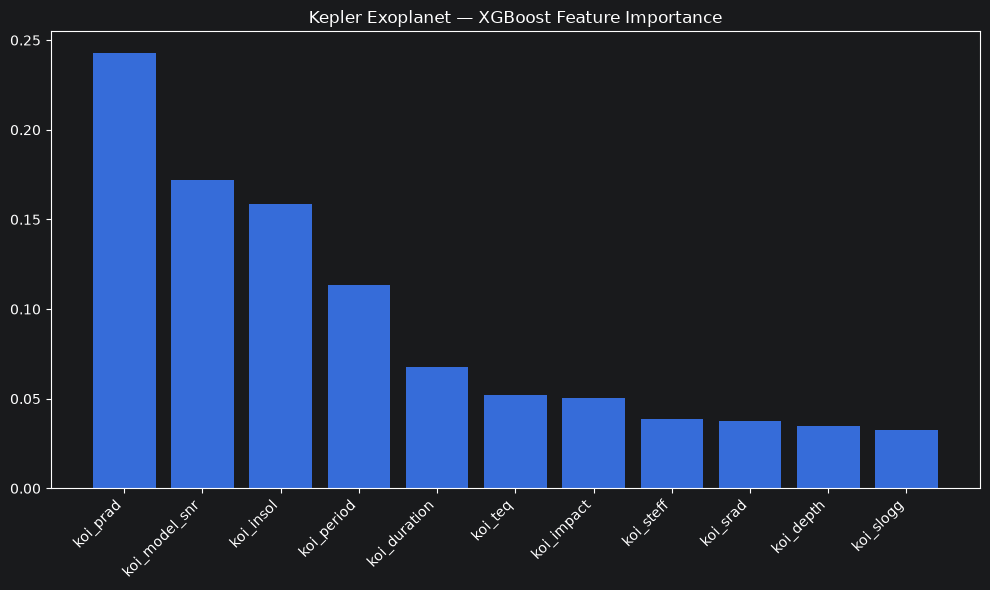

In [7]:
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(features)), importances[indices])
plt.xticks(range(len(features)),
           [features[i] for i in indices], rotation=45, ha='right')
plt.title('Kepler Exoplanet — XGBoost Feature Importance')
plt.tight_layout()
plt.savefig('kepler_feature_importance.png', dpi=150)
plt.show()